<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
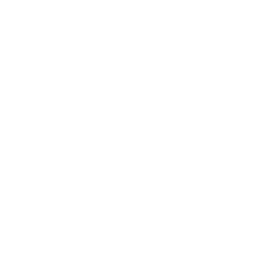
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Identificação de Regimes de Mercado</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Finanças Quantitativas / Gestão de Ativos &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Este exemplo usa o **PROC ACECLUS** para encontrar a estrutura latente que separa os regimes de mercado e, em seguida, agrupa com base nela. A partir de 100 observações semanais de 10 características de mercado (retorno e volatilidade de ações, spreads de crédito e de high yield, a curva 2y/10y, o dólar, commodities e uma variação do VIX), o ACECLUS estima uma covariância aproximada intrarregime *sem* usar qualquer rótulo de regime e deriva variáveis canônicas ao longo das quais os regimes se separam.

No limiar P=0.02, o algoritmo converge em duas iterações e retém **três dimensões canônicas**, que juntas respondem por toda a dispersão entre regimes (proporções de autovalores de 57.8%, 24.4%, 17.8%). Um limiar mais frouxo de P=0.05 suaviza demais a covariância e **colapsa a estrutura para uma única dimensão** — um alerta útil de que o limiar molda materialmente o resultado.

Alimentando as três variáveis canônicas no **PROC FASTCLUS** (k=4), obtém-se uma ordenação limpa por severidade de estresse das 100 semanas (R² geral = 0.51, pseudo F = 33.2): um núcleo calmo de 62 semanas, um grupo de recuperação/redução de volatilidade de 22 semanas, um grupo de estresse elevado de 12 semanas e um grupo de crise profunda de 4 semanas com spreads de high yield em média de ~1,514 bps. Essas atribuições são exportadas para o condicionamento de risco de carteira a jusante.

## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|--------|
| WORK.MARKET_WEEKLY | Observações semanais de características de mercado em diversas classes de ativos | 100 |
| Variáveis: eq_return_pct, eq_vol_idx, credit_spread_bps, hy_spread_bps, yield_2y, yield_10y, term_spread, usd_index_chg, commodities_ret, vix_chg |

A série é gerada por um processo de mudança de regime de Markov de cinco estados (expansão em alta, fim de ciclo, risk-off, crise, recuperação) com distribuições de características condicionais ao regime. Executando sem licença, a tabela de características é limitada às primeiras 100 observações semanais (~2 anos) — uma janela dominada pela alta que também passa por uma breve crise e recuperação. Os retornos semanais e as variações de nível representam os movimentos de preço de fim de semana; os spreads estão em pontos-base e a volatilidade é um índice no estilo VIX.

---

In [1]:
/* --------------------------------------------------------
   Gera um histórico semanal de mercado multiativos com
   cinco estados de regime embutidos, conduzidos por um
   processo de mudança de regime de Markov. Este exemplo
   roda sem licença, então a tabela de características
   abaixo é limitada às primeiras 100 observações semanais
   (~2 anos) -- uma janela dominada por alta pontuada por
   uma breve crise e recuperação.
   -------------------------------------------------------- */
DADOS work.market_weekly;
    CHAMAR streaminit(42);
    /* 5 regimes: 1=Alta, 2=Fim-de-Ciclo, 3=Risk-Off, 4=Crise, 5=Recuperação */
    VETOR regime_names[5] $16 _temporary_
        ('EXPANSAO_ALTA' 'FIM_DE_CICLO' 'RISK_OFF'
         'CRISE' 'RECUPERACAO');
    RETER current_regime 1;
    FAZER week_id = 1 ATÉ 5000;
        /* Mudança de regime de Markov */
        u = rand('uniform');
        SE current_regime = 1 ENTÃO FAZER; /* Alta: longa duração */
            SE u > 0.97 ENTÃO current_regime = 2;
        FIM;
        SENÃO SE current_regime = 2 ENTÃO FAZER; /* Fim de ciclo */
            SE u > 0.92 ENTÃO current_regime = 3;
        FIM;
        SENÃO SE current_regime = 3 ENTÃO FAZER; /* Risk-off */
            SE u > 0.80 ENTÃO current_regime = 4;
            SENÃO SE u < 0.10 ENTÃO current_regime = 1;
        FIM;
        SENÃO SE current_regime = 4 ENTÃO FAZER; /* Crise: curta */
            SE u > 0.75 ENTÃO current_regime = 5;
        FIM;
        SENÃO SE current_regime = 5 ENTÃO FAZER; /* Recuperação */
            SE u > 0.85 ENTÃO current_regime = 1;
        FIM;
        regime_label = regime_names[current_regime];
        /* Distribuições de características condicionais ao regime */
        SE current_regime = 1 ENTÃO FAZER;  /* Alta */
            eq_return_pct  = round(rand('normal',  0.35, 1.2), 0.001);
            eq_vol_idx     = round(rand('normal', 14, 3), 0.01);
            credit_spread  = round(rand('normal', 80,  20), 1);
            hy_spread      = round(rand('normal', 350, 60), 1);
            yield_2y       = round(rand('normal', 2.8, 0.5), 0.01);
            yield_10y      = round(rand('normal', 3.5, 0.6), 0.01);
        FIM;
        SENÃO SE current_regime = 2 ENTÃO FAZER;  /* Fim de ciclo */
            eq_return_pct  = round(rand('normal',  0.10, 1.5), 0.001);
            eq_vol_idx     = round(rand('normal', 18, 4), 0.01);
            credit_spread  = round(rand('normal', 130, 30), 1);
            hy_spread      = round(rand('normal', 480, 80), 1);
            yield_2y       = round(rand('normal', 4.2, 0.4), 0.01);
            yield_10y      = round(rand('normal', 4.0, 0.5), 0.01);
        FIM;
        SENÃO SE current_regime = 3 ENTÃO FAZER;  /* Risk-off */
            eq_return_pct  = round(rand('normal', -0.60, 2.2), 0.001);
            eq_vol_idx     = round(rand('normal', 28, 7), 0.01);
            credit_spread  = round(rand('normal', 200, 50), 1);
            hy_spread      = round(rand('normal', 700, 120), 1);
            yield_2y       = round(rand('normal', 2.0, 0.8), 0.01);
            yield_10y      = round(rand('normal', 2.8, 0.7), 0.01);
        FIM;
        SENÃO SE current_regime = 4 ENTÃO FAZER;  /* Crise */
            eq_return_pct  = round(rand('normal', -2.50, 3.5), 0.001);
            eq_vol_idx     = round(rand('normal', 52, 14), 0.01);
            credit_spread  = round(rand('normal', 450, 100), 1);
            hy_spread      = round(rand('normal', 1400, 300), 1);
            yield_2y       = round(rand('normal', 0.5, 0.5), 0.01);
            yield_10y      = round(rand('normal', 1.8, 0.6), 0.01);
        FIM;
        SENÃO FAZER;  /* Recuperação */
            eq_return_pct  = round(rand('normal',  0.55, 1.8), 0.001);
            eq_vol_idx     = round(rand('normal', 22, 6), 0.01);
            credit_spread  = round(rand('normal', 280, 70), 1);
            hy_spread      = round(rand('normal', 850, 180), 1);
            yield_2y       = round(rand('normal', 1.2, 0.6), 0.01);
            yield_10y      = round(rand('normal', 2.5, 0.5), 0.01);
        FIM;
        term_spread    = round(yield_10y - yield_2y + rand('normal', 0, 0.15), 0.01);
        usd_index_chg  = round(rand('normal', 0, 0.8), 0.001);
        commodities_ret = round(rand('normal', 0, 1.5) - (current_regime = 4) * 1.2, 0.001);
        vix_chg        = round(eq_vol_idx - lag(eq_vol_idx), 0.01);
        SE week_id = 1 ENTÃO vix_chg = 0;
        SAÍDA;
    FIM;
    REMOVER u;
    RENOMEAR credit_spread = credit_spread_bps
           hy_spread     = hy_spread_bps;
EXECUTAR;


NOTE: DATA work.market_weekly

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.market_weekly (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.32 seconds
  cpu   1.32 seconds


---

In [2]:
/* --------------------------------------------------------
   Distribuições de base das variáveis de mercado por regime
   -------------------------------------------------------- */
TÍTULO "Distribuições de Base das Variáveis de Mercado por Regime";
PROCEDIMENTO MÉDIAS DADOS=work.market_weekly n mean std MIN MAX;
    CLASSE regime_label;
    VARIÁVEL eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    RÓTULO regime_label="Regime de Mercado"
        eq_return_pct="Retorno Semanal de Ações (%)"
        eq_vol_idx="Índice de Volatilidade (proxy VIX)"
        credit_spread_bps="Spread de Crédito (pb)"
        hy_spread_bps="Spread High Yield (pb)"
        term_spread="Spread de Prazo"
        vix_chg="Variação do VIX";
EXECUTAR;

                               Distribuições de Base das Variáveis de Mercado por Regime                                

                                                  The MEANS Procedure

                            Analysis Variable : eq_return_pct Retorno Semanal de Ações (%)

        Regime de Mercado          N Obs           Mean        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------------
        CRISE                         12     -2.3403333      3.9436692     -8.0160000      3.7360000
        EXPANSAO_ALTA                 28      0.2860000      1.0226518     -1.5980000      2.2150000
        FIM_DE_CICLO                  39      0.0364359      1.9733801     -4.6010000      3.7030000
        RECUPERACAO                    4      0.0077500      1.5951747     -0.8330000      2.4000000
        RISK_OFF                      17     -0.8447059      1.2832441     -3.3850000      1.1810000
        


NOTE: Option TITLE changed to Distribuições de Base das Variáveis de Mercado por Regime.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                               Distribuições de Base das Variáveis de Mercado por Regime                                




NOTE: PROC SGPLOT data=work.market_weekly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


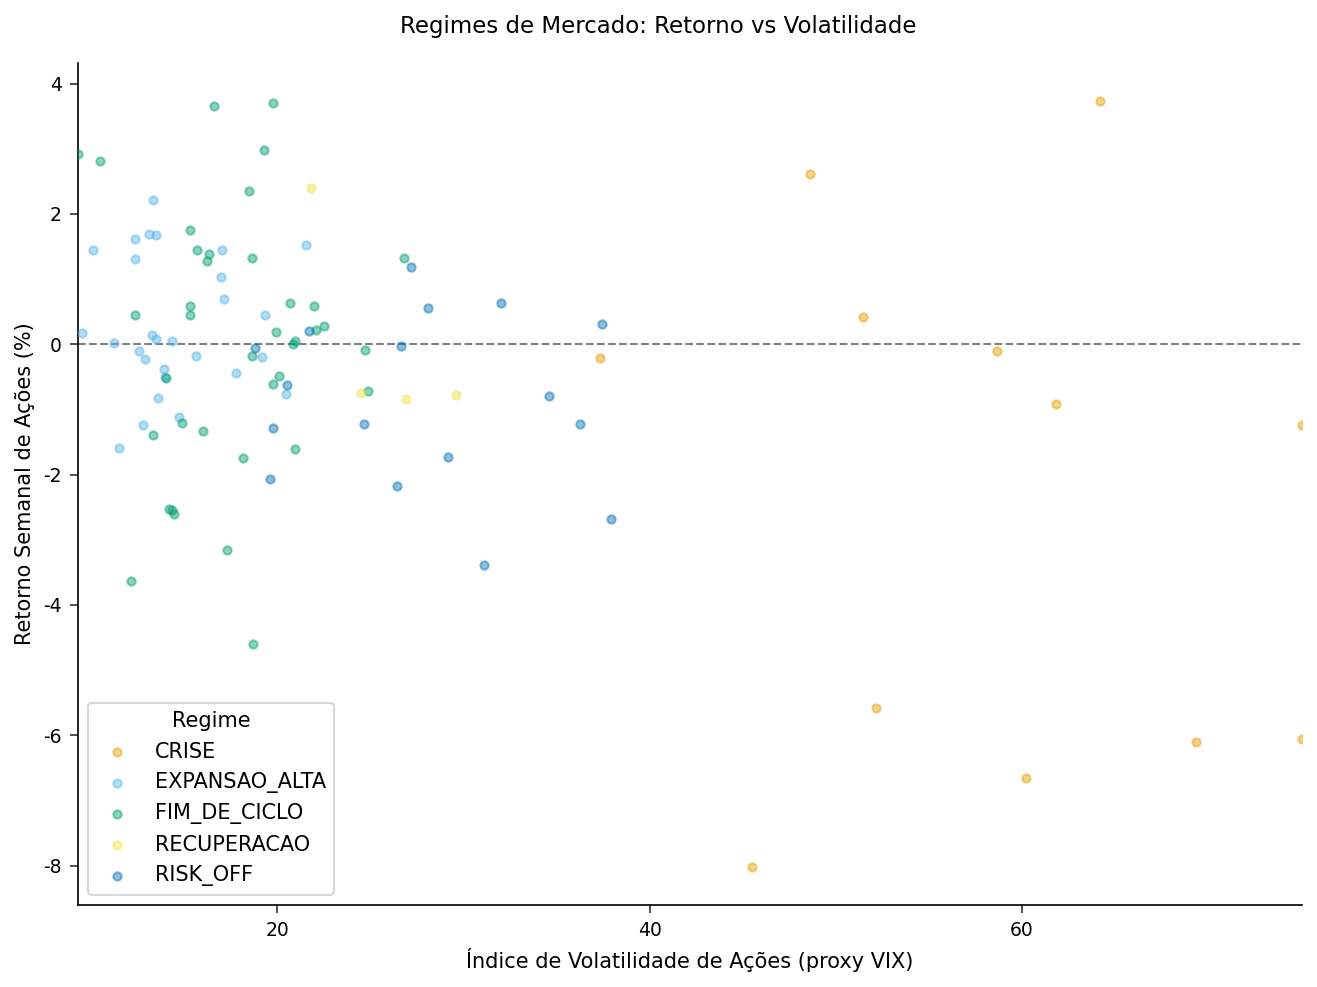

In [3]:
/* --------------------------------------------------------
   Retorno de ações vs índice de volatilidade por regime
   -------------------------------------------------------- */
PROCEDIMENTO SGPLOT DADOS=work.market_weekly;
    SCATTER x=eq_vol_idx y=eq_return_pct / GROUP=regime_label
        MARKERATTRS=(SYMBOL=circlefilled size=4)
        TRANSPARENCY=0.55;
    REFLINE 0 / AXIS=y LINEATTRS=(color=gray pattern=dash);
    XAXIS RÓTULO="Índice de Volatilidade de Ações (proxy VIX)";
    YAXIS RÓTULO="Retorno Semanal de Ações (%)";
    keylegend / TÍTULO="Regime";
    TÍTULO "Regimes de Mercado: Retorno vs Volatilidade";
EXECUTAR;

---

In [4]:
/* --------------------------------------------------------
   Estimação aproximada da covariância intrarregime.
   O ACECLUS estima a covariância intragrupo agrupada sem
   conhecer os rótulos dos grupos, depois deriva variáveis
   canônicas que separam os regimes. P=0.02 define o limiar
   de distância par a par: apenas os ~2% de pares de
   observações mais próximos são tratados como mesmo regime.
   -------------------------------------------------------- */
TÍTULO "ACECLUS: Covariância Canônica Intrarregime (P=0.02)";
PROCEDIMENTO aceclus DADOS=work.market_weekly
             out=work.regime_canonical
             p=0.02;
    VARIÁVEL eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
EXECUTAR;


                                  ACECLUS: Covariância Canônica Intrarregime (P=0.02)                                   

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0200  Converge  0.00100
Threshold = 2.578941

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.


NOTE: Option TITLE changed to ACECLUS: Covariância Canônica Intrarregime (P=0.02).
NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.02) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [5]:
/* --------------------------------------------------------
   Verificação de sensibilidade em P=0.05 -- um limiar de
   mesmo regime mais frouxo inclui mais pares, inflando a
   covariância intrarregime estimada. Compare a estrutura
   canônica (autovalores e dimensões retidas) com a
   solução P=0.02.
   -------------------------------------------------------- */
TÍTULO "ACECLUS: Análise de Sensibilidade (P=0.05)";
PROCEDIMENTO aceclus DADOS=work.market_weekly
             out=work.regime_canonical_p05
             p=0.05;
    VARIÁVEL eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
EXECUTAR;


                                       ACECLUS: Análise de Sensibilidade (P=0.05)                                       

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0500  Converge  0.00100
Threshold = 2.899704

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.


NOTE: Option TITLE changed to ACECLUS: Análise de Sensibilidade (P=0.05).
NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.05) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [6]:
/* --------------------------------------------------------
   k-means sobre as variáveis canônicas do ACECLUS. O
   ACECLUS reteve três dimensões canônicas (Can1-Can3),
   então o agrupamento roda sobre elas. Quatro grupos
   visam os quatro estados de mercado bem populados.
   -------------------------------------------------------- */
TÍTULO "k-means sobre as Variáveis Canônicas do ACECLUS";
PROCEDIMENTO FASTCLUS DADOS=work.regime_canonical
              maxclusters=4
              MAXITER=100
              CONVERGE=0.0001
              out=work.regime_assignments
              OUTSTAT=work.regime_stats;
    VARIÁVEL can1 can2 can3;
EXECUTAR;


                                    k-means sobre as Variáveis Canônicas do ACECLUS                                     


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  12         1.4206             5.2684              2         3.0063
2                  62         0.5751             1.7953              3         2.1641
3                  22         1.2227             6.5386              2         2.1641
4


NOTE: Option TITLE changed to k-means sobre as Variáveis Canônicas do ACECLUS.
NOTE: PROC FASTCLUS data=work.regime_canonical maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 3 variables, 4 clusters using k-means


                                     Agrupamento de Regime vs Rótulo de Regime Real                                     

                                                   The FREQ Procedure

Table of Agrupamento by Regime de Mercado

Agrupamento |        CRISE |EXPANSAO_ALTA | FIM_DE_CICLO |  RECUPERACAO |     RISK_OFF |         Total
------------+--------------+--------------+--------------+--------------+--------------+--------------
1           |            4 |            2 |            2 |            0 |            4 |            12
            |         4.00 |         2.00 |         2.00 |         0.00 |         4.00 |         12.00
------------+--------------+--------------+--------------+--------------+--------------+--------------
2           |            3 |           21 |           28 |            3 |            7 |            62
            |         3.00 |        21.00 |        28.00 |         3.00 |         7.00 |         62.00
------------+--------------+--------------+


NOTE: Option TITLE changed to Agrupamento de Regime vs Rótulo de Regime Real.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_regime_label.spec.json
NOTE: PROC FREQ statement used.


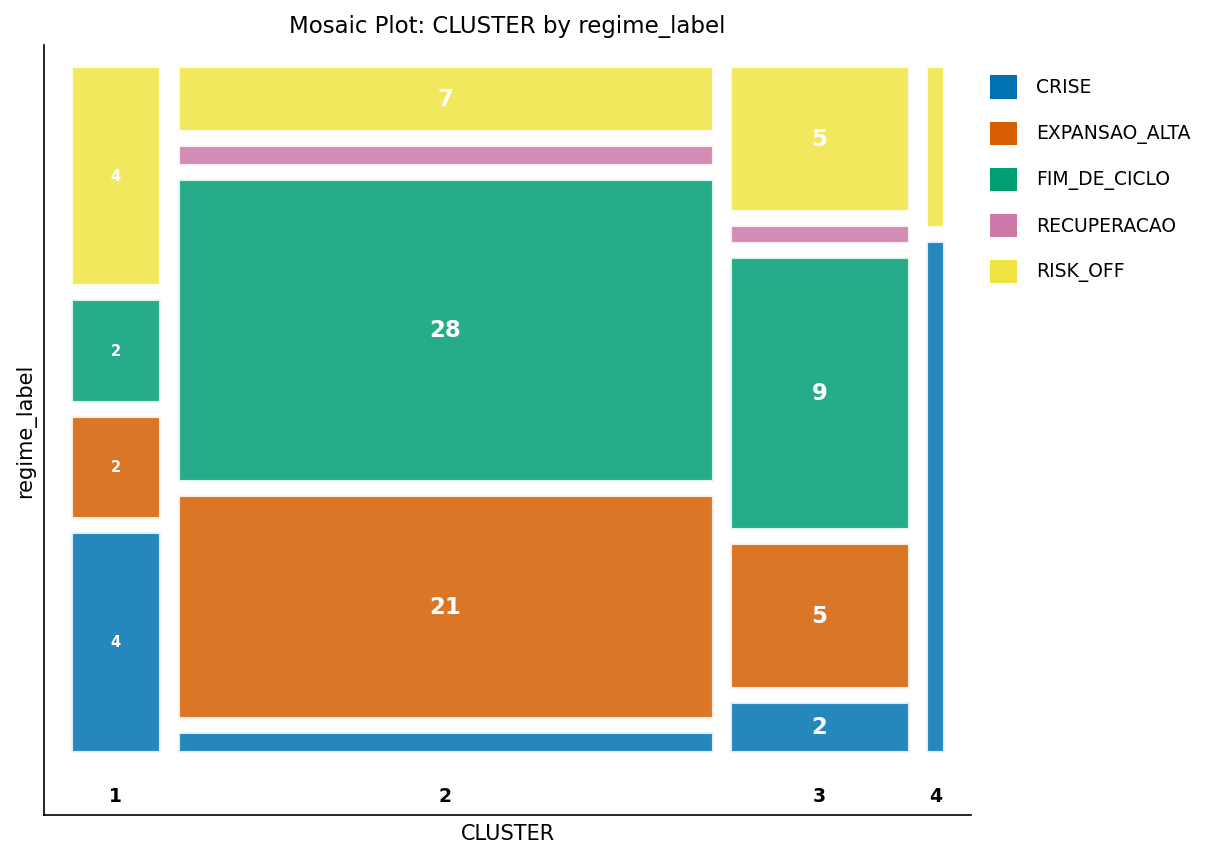

In [7]:
/* --------------------------------------------------------
   Valida os grupos atribuídos contra os rótulos de regime
   conhecidos da geração de dados
   -------------------------------------------------------- */
TÍTULO "Agrupamento de Regime vs Rótulo de Regime Real";
PROCEDIMENTO FREQUÊNCIAS DADOS=work.regime_assignments;
    TABLES CLUSTER * regime_label / norow nocol;
    RÓTULO CLUSTER="Agrupamento" regime_label="Regime de Mercado";
EXECUTAR;

In [8]:
/* --------------------------------------------------------
   Perfila as médias das características por grupo para interpretação
   -------------------------------------------------------- */
TÍTULO "Médias das Variáveis de Mercado por Agrupamento";
PROCEDIMENTO MÉDIAS DADOS=work.regime_assignments mean;
    CLASSE CLUSTER;
    VARIÁVEL eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    RÓTULO CLUSTER="Agrupamento"
        eq_return_pct="Retorno Semanal de Ações (%)"
        eq_vol_idx="Índice de Volatilidade (proxy VIX)"
        credit_spread_bps="Spread de Crédito (pb)"
        hy_spread_bps="Spread High Yield (pb)"
        term_spread="Spread de Prazo"
        vix_chg="Variação do VIX";
EXECUTAR;

                                    Médias das Variáveis de Mercado por Agrupamento                                     

                                                  The MEANS Procedure

                                           Analysis Variable : eq_return_pct Retorno Semanal de Ações (%)

                                                            N
                                           Agrupamento    Obs            Mean
                                           ----------------------------------
                                           1               12      -2.0955000
                                           2               62      -0.3638871
                                           3               22       0.7421364
                                           4                4      -0.4010000
                                           ----------------------------------

                                           Analysis Variable : eq_vol_idx Índice de Volatil


NOTE: Option TITLE changed to Médias das Variáveis de Mercado por Agrupamento.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Interpretação

**Estrutura canônica do ACECLUS.** Na amostra de 100 semanas, o PROC ACECLUS (P=0.02, limiar = 2.578941) convergiu em duas iterações e produziu três variáveis canônicas. Seus autovalores de `Inv(ACE)*(COV-ACE)` são 0.0219, 0.0093 e 0.0067, ou seja, proporções de 57.8%, 24.4% e 17.8% (cumulativo 100%). O primeiro eixo canônico carrega o contraste dominante risk-on/risk-off; o segundo e o terceiro o refinam. Como as características de volatilidade de ações e de spread se movem fortemente em conjunto, o ACECLUS incorpora essa variação compartilhada na covariância intrarregime, de modo que os eixos canônicos reflitam uma separação genuína entre regimes em vez de escala comum.

**Sensibilidade ao limiar.** Reexecutar com P=0.05 eleva o limiar de distância para 2.899704, o que atrai 4,949 dos 4,950 pares de observações para dentro do corte. A covariância intrarregime estimada então quase se iguala à covariância total, e a estrutura canônica **colapsa para uma única dimensão** (um autovalor, 0.0096, a 100%). As soluções P=0.02 e P=0.05 são, portanto, *não* intercambiáveis aqui — um limiar mais frouxo apaga os eixos de regime mais finos, de modo que o limiar mais restrito é a especificação mais informativa para esta amostra.

**Agrupamento nas variáveis canônicas.** O PROC FASTCLUS (k=4) em Can1–Can3 dá um R² geral de 0.5089 e um pseudo F de 33.16. Can2 realiza a maior parte do trabalho de separação (R² = 0.626), Can1 contribui moderadamente (R² = 0.359) e Can3 não acrescenta praticamente nada (R² = 0.000) — consistente com apenas dois eixos carregando sinal forte. Os quatro clusters se alinham como um gradiente de estresse de mercado:

| Cluster | n | Retorno Médio de Ações | VIX Médio | Spread HY Médio | Variação Média do VIX | Leitura |
|---------|---|----------------|----------|----------------|-----------------|---------|
| 2 | 62 | -0.36% | 20.4 | 534 bps | +1.2 | Núcleo calmo (alta / fim de ciclo) |
| 3 | 22 | +0.74% | 20.5 | 539 bps | -9.6 | Recuperação, volatilidade em queda |
| 1 | 12 | -2.10% | 39.0 | 720 bps | +11.3 | Estresse elevado, volatilidade em disparada |
| 4 |  4 | -0.40% | 47.4 | 1,514 bps | +0.1 | Crise profunda, estresse de crédito extremo |

**Cluster vs. regime verdadeiro.** A tabela cruzada mostra que os clusters não se mapeiam de forma um-para-um nos cinco rótulos geradores — o que é esperado, pois os rótulos se sobrepõem fortemente no espaço de características com este tamanho de amostra. O grande cluster calmo (62) absorve a maioria das semanas de alta (21) e de fim de ciclo (28); o cluster de crise profunda (4) é quase inteiramente composto pelas semanas de crise mais extremas (3 de 4). Os eixos canônicos, portanto, organizam as semanas por *severidade*, não por rótulo exato, o que é o sinal mais acionável para o condicionamento de risco.

**Uso.** As atribuições semanais exportadas apoiam o condicionamento tático: reduzir risco e estender a duração à medida que as semanas migram para os Clusters 1 e 4, e reassumir risco à medida que retornam ao núcleo calmo (Cluster 2) ou ao grupo em recuperação (Cluster 3).

---

In [9]:
/* --------------------------------------------------------
   Exporta as atribuições semanais de regime para
   condicionamento do modelo de risco da carteira e
   geração de sinais
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=work.regime_assignments
    OUTFILE='market_regime_assignments.csv'
    DBMS=csv REPLACE;
EXECUTAR;


NOTE: PROC EXPORT data=work.regime_assignments outfile=market_regime_assignments.csv

NOTE: Exported 100 rows to market_regime_assignments.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido com <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>